# AutoKeras API – Fashion Product Image Classification

In this notebook I’m not trying to build the best model yet.  
The goal here is just to show how I wrapped the core pieces of the project into a small API:

- `utils_data_io.py`  
  - `tsv_to_tfds(tsv_path, num_classes)` → load TSV lists into a `tf.data.Dataset`
  - `ds_to_numpy(ds, max_samples)` → turn a small dataset into NumPy arrays

- `utils_model.py`  
  - `make_baseline_cnn(input_shape, num_classes)` → simple CNN baseline
  - `make_autokeras_image_classifier(num_classes, max_trials)` → AutoKeras ImageClassifier factory

This notebook is basically a “how to use my API” demo:
- load a tiny sample of images  
- build a CNN using just one function call  
- show how the AutoKeras wrapper is meant to be used

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # 0 = all, 1 = info, 2 = warnings, 3 = errors only

In [2]:
# Core libraries
import tensorflow as tf

# My own helper modules for this project
from utils_data_io import tsv_to_tfds, ds_to_numpy
from utils_model import make_baseline_cnn, make_autokeras_image_classifier

# Just to quickly check TensorFlow version and device
print("TensorFlow version:", tf.__version__)
print("Available GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
Available GPUs: []


2025-12-05 06:36:24.684737: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [3]:
# I keep the config here so it's easy to reuse in other notebooks as well.
NUM_CLASSES = 6
CLASS_NAMES = [
    "Accessories",
    "Apparel",
    "Footwear",
    "Free Items",
    "Personal Care",
    "Sporting Goods",
]

TRAIN_TSV = "lists/train.tsv"

# This uses the helper I wrote in utils_data_io.py.
# It reads the TSV file and returns a tf.data.Dataset of (image, label).
train_ds = tsv_to_tfds(TRAIN_TSV, num_classes=NUM_CLASSES)

# For the API demo I don’t need the full dataset.
# I’ll just grab a small subset so this runs quickly inside Docker.
small_train_ds = train_ds.shuffle(2000).take(64)

X_small, y_small = ds_to_numpy(small_train_ds, max_samples=64)

X_small.shape, y_small.shape

((64, 224, 224, 3), (64,))

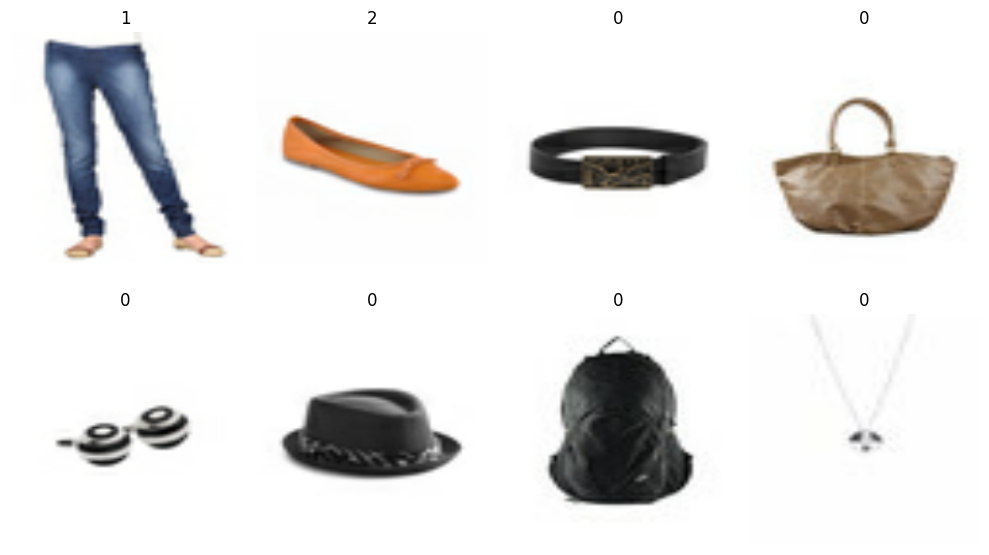

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Just to sanity check that the pipeline is working,
# I plot a few images with their label indices.
plt.figure(figsize=(10, 6))

for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(X_small[i].astype("uint8"))
    plt.axis("off")
    plt.title(int(y_small[i]))

plt.tight_layout()
plt.show()

In [5]:
# Here I call my baseline factory function instead of writing the whole model inline.
# This keeps the notebook cleaner and pushes the architecture details into utils_model.py.

baseline_model = make_baseline_cnn(
    input_shape=X_small.shape[1:],  # (224, 224, 3)
    num_classes=NUM_CLASSES,
)

baseline_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,785,158 (98.36 MB)

 Trainable params: 25,785,158 (98.36 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Since this is the API notebook, I don’t train for many epochs.
# The goal is just to prove that the model compiles and can overfit a tiny batch.

EPOCHS_DEMO = 1
BATCH_SIZE = 16

history = baseline_model.fit(
    X_small,
    y_small,
    epochs=EPOCHS_DEMO,
    batch_size=BATCH_SIZE,
    validation_split=0.2,  # I just carve out a small validation split from this mini-batch
)

4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 534ms/step - accuracy: 0.4118 - loss: 4.2434 - val_accuracy: 0.1538 - val_loss: 1.7470


In [7]:
# Now I switch to the AutoKeras side.
# In the example notebook I’ll actually run a proper search,
# but here I just show how the factory is supposed to be used.

try:
    clf = make_autokeras_image_classifier(
        num_classes=NUM_CLASSES,
        max_trials=2,   # small number here, just to keep it light
    )
    print("AutoKeras ImageClassifier created successfully.")
    print(clf)
except Exception as e:
    # If for some reason AutoKeras is not installed in the environment,
    # I don't want this notebook to crash – I just log the error.
    print("Could not create AutoKeras classifier:", e)

AutoKeras ImageClassifier created successfully.


In [8]:
# This is how I would call fit() on the classifier in practice:
#
# ak_train_ds = train_ds.batch(32)
# ak_val_ds   = val_ds.batch(32)  # val_ds will be defined in the example notebook
#
# clf.fit(
#     ak_train_ds,
#     epochs=5,
#     validation_data=ak_val_ds,
# )
#
# For the full experiment and comparison with the baseline CNN,
# see AutoKeras.example.ipynb.